# *ASSIGNMENT-3: Sending messages through a network*

In [1]:
import networkx as nx
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import random
import numpy as np
from itertools import combinations

In [2]:
BASE_DIR = Path().resolve().parent.parent
DATASET_PATH = BASE_DIR / "data" / "anime_filtered.csv"
df = pd.read_csv(DATASET_PATH)

In [3]:
def build_graph(filtered):
    G = nx.Graph()
    for _, row in filtered.iterrows():
        G.add_node(row["mal_id"], title=row["title"])
    for (_, a), (_, b) in combinations(filtered.iterrows(), 2):
        genres_a = set(str(a["genres"]).split("|"))
        genres_b = set(str(b["genres"]).split("|"))
        if len(genres_a & genres_b) >= 2:
            G.add_edge(a["mal_id"], b["mal_id"])
    return G

In [4]:
def initialize_roles(G, num_verifiers=10, num_unintentional=10):
    # Inizializza tutti i nodi
    for node in G.nodes():
        G.nodes[node]["type"] = "normal"
        G.nodes[node]["message"] = None

    nodes = list(G.nodes())
    # Verifiers
    verifiers = random.sample(nodes, num_verifiers)
    for v in verifiers:
        G.nodes[v]["type"] = "verifier"
        G.nodes[v]["message"] = "true"
    # Unintentional
    remaining = list(set(nodes) - set(verifiers))
    unintentional = random.sample(remaining, num_unintentional)
    for u in unintentional:
        G.nodes[u]["type"] = "unintentional"
    return G

In [5]:
def spread_step(G, threshold=0.3):
    changes = {}
    for node in G.nodes():
        if G.nodes[node]["message"] is not None:
            continue
        neighbors = list(G.neighbors(node))
        if len(neighbors) == 0:
            continue
        true_count = sum(G.nodes[n]["message"] == "true" for n in neighbors)
        false_count = sum(G.nodes[n]["message"] == "false" for n in neighbors)
        if max(true_count, false_count) / len(neighbors) < threshold:
            continue
        if G.nodes[node]["type"] == "unintentional":
            changes[node] = "false"
        else:
            changes[node] = "true" if true_count >= false_count else "false"
    for n, msg in changes.items():
        G.nodes[n]["message"] = msg
    return len(changes)

In [6]:
G = build_graph(filtered=df)
G = initialize_roles(G, num_verifiers=15, num_unintentional=20)
for i in range(20):
    changed = spread_step(G, threshold=0.05)
    print(i, changed)
    if changed == 0:
        break

0 0


In [7]:
true = sum(1 for n in G.nodes() if G.nodes[n]["message"] == "true")
false = sum(1 for n in G.nodes() if G.nodes[n]["message"] == "false")
none = sum(1 for n in G.nodes() if G.nodes[n]["message"] is None)

print("True:", true)
print("False:", false)
print("None:", none)

True: 15
False: 0
None: 3564


In [8]:
def run_experiment(unintentional_list):
    results = []
    G_base = build_graph(df)
    for u in unintentional_list:
        avg_false = []
        for _ in range(10):
            G = G_base.copy()
            G = initialize_roles(G, num_verifiers=15, num_unintentional=u)
            for _ in range(20):
                if spread_step(G, 0.05) == 0:
                    break

            total = G.number_of_nodes()
            false = sum(
                G.nodes[n]["message"] == "false"
                for n in G.nodes()
            )
            avg_false.append(false / total * 100)
        results.append(np.mean(avg_false))
    return results

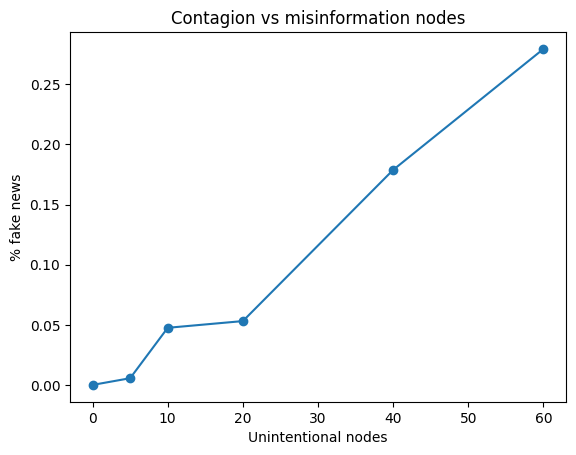

In [9]:
vals = [0, 5, 10, 20, 40, 60]
res = run_experiment(vals)

plt.plot(vals, res, marker="o")
plt.xlabel("Unintentional nodes")
plt.ylabel("% fake news")
plt.title("Contagion vs misinformation nodes")
plt.show()